In [19]:
# Cell 1
# =============================================================================
# Load Artifacts, Node Test Datasets, & Concatenate All Predictions
# =============================================================================

import os
import joblib
import numpy as np
import pandas as pd

MODELS_DIR = "models"
BASE_DIR = "dataset/normalized"
NODES = ["A", "B", "C", "D", "E", "F", "G", "H"]

# -----------------------------------------------------------------------------
# 1. Load Node-Specific Predictions for Model 1 and Model 2 (2:1 Weighted)
# -----------------------------------------------------------------------------
df_pred_hw_agg_list = []
df_pred_full_list = []

for node in NODES:
    p_m1 = os.path.join(MODELS_DIR, f"Node_{node}_predictions_test_rf_context_own_hw_plus_agg_w2.csv")
    p_m2 = os.path.join(MODELS_DIR, f"Node_{node}_predictions_test_rf_context_full_w2.csv")
    
    df_pred_hw_agg_list.append(pd.read_csv(p_m1))
    df_pred_full_list.append(pd.read_csv(p_m2))

df_pred_hw_agg = pd.concat(df_pred_hw_agg_list, ignore_index=True)
df_pred_full   = pd.concat(df_pred_full_list, ignore_index=True)

# Load representative label encoder
le_context = joblib.load(os.path.join(MODELS_DIR, f"Node_{NODES[0]}_label_encoder_context_w2.joblib"))
classes = le_context.classes_

# -----------------------------------------------------------------------------
# 2. Load Baseline Model Artifacts and Predict on Full Test Set
# -----------------------------------------------------------------------------
rf_base = joblib.load(os.path.join(MODELS_DIR, "rf_final.joblib"))
le_base = joblib.load(os.path.join(MODELS_DIR, "label_encoder.joblib"))
scaler_base = joblib.load(os.path.join(MODELS_DIR, "scaler.joblib"))

# Feature definition for baseline model (own hardware features + State)
base_feature_cols = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW", "State"]
base_numeric_cols = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW"]
base_expected_order = [
    "shunt_voltage", "bus_voltage_V", "current_mA", "power_mW",
    "State_idle", "State_charging"
]

# Concatenate all raw node test sets
test_files = [os.path.join(BASE_DIR, f"Node_{node}_test_normalized.csv") for node in NODES]
df_test_raw = pd.concat([pd.read_csv(p) for p in test_files], ignore_index=True)

# Prepare baseline features
X_base_raw = df_test_raw[base_feature_cols].copy()
X_base_encoded = pd.get_dummies(X_base_raw, columns=["State"], drop_first=False)
for col in ["State_idle", "State_charging"]:
    if col not in X_base_encoded.columns:
        X_base_encoded[col] = 0
X_base_ordered = X_base_encoded[base_expected_order].copy()
X_base_ordered[base_numeric_cols] = scaler_base.transform(X_base_ordered[base_numeric_cols])
X_base_np = X_base_ordered.to_numpy()

# Generate baseline predictions and class probabilities
y_base_pred_idx = rf_base.predict(X_base_np)
y_base_proba = rf_base.predict_proba(X_base_np)

df_pred_base = pd.DataFrame()
df_pred_base["Attack"] = df_test_raw["Attack"]
df_pred_base["prediction"] = le_base.inverse_transform(y_base_pred_idx)
for idx, cls_name in enumerate(le_base.classes_):
    df_pred_base[f"prob_{cls_name}"] = y_base_proba[:, idx]

# Export baseline combined predictions
df_pred_base.to_csv(os.path.join(MODELS_DIR, "predictions_test_rf_baseline.csv"), index=False)

print(f"Loaded label encoder and prediction sets from '{MODELS_DIR}'.")
print(f"Target Attack Classes: {classes}")
print(f"Total Test Samples Evaluated across all {len(NODES)} nodes: {len(df_pred_base)}")
print(f"Model 1 (HW + Agg Context) Total Predictions: {len(df_pred_hw_agg)}")
print(f"Model 2 (Full Context) Total Predictions:     {len(df_pred_full)}")

Loaded label encoder and prediction sets from 'models'.
Target Attack Classes: ['Backdoor' 'none' 'syn-flood']
Total Test Samples Evaluated across all 8 nodes: 174408
Model 1 (HW + Agg Context) Total Predictions: 174408
Model 2 (Full Context) Total Predictions:     174408


In [20]:
# Cell 2
# =============================================================================
# Metric Benchmarking: 3-Model Comparison Summary Table
# =============================================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
    mean_squared_error,
    roc_auc_score,
)

def compute_model_metrics(df_preds, model_name):
    """
    Computes standard evaluation metrics: Accuracy, Macro F1, Weighted F1,
    Mean Squared Error, Multi-class Log Loss, and One-vs-Rest Macro ROC-AUC.
    """
    y_true_enc = le_context.transform(df_preds["Attack"])
    y_pred_enc = le_context.transform(df_preds["prediction"])
    
    prob_cols = [f"prob_{cls_name}" for cls_name in classes]
    y_proba = df_preds[prob_cols].values
    
    num_classes = len(classes)
    labels_arr = np.arange(num_classes)
    
    acc = accuracy_score(y_true_enc, y_pred_enc)
    macro_f1 = f1_score(y_true_enc, y_pred_enc, average="macro")
    weighted_f1 = f1_score(y_true_enc, y_pred_enc, average="weighted")
    mse_error = mean_squared_error(y_true_enc, y_pred_enc)
    loss = log_loss(y_true_enc, y_proba, labels=labels_arr)
    
    try:
        roc_auc = roc_auc_score(
            y_true_enc, y_proba, multi_class="ovr", average="macro", labels=labels_arr
        )
    except ValueError:
        roc_auc = np.nan
    
    return {
        "Model Configuration": model_name,
        "Accuracy": round(acc, 6),
        "Macro F1": round(macro_f1, 6),
        "Weighted F1": round(weighted_f1, 6),
        "MSE": round(mse_error, 6),
        "Log Loss": round(loss, 6),
        "ROC-AUC (Macro OVR)": round(roc_auc, 6)
    }

# Benchmark Baseline RF against both Context-Aware configurations
metrics_summary = [
    compute_model_metrics(df_pred_base, "Baseline RF (Own HW + State)"),
    compute_model_metrics(df_pred_hw_agg, "Model 1: Context RF (Own HW [2x] + Agg Context)"),
    compute_model_metrics(df_pred_full, "Model 2: Full Context RF (Own HW/Probs [2x] + Agg Context)")
]

df_metrics = pd.DataFrame(metrics_summary)
print("=== 3-Model Performance Comparison ===")
print(df_metrics.to_string(index=False))

=== 3-Model Performance Comparison ===
                                       Model Configuration  Accuracy  Macro F1  Weighted F1      MSE  Log Loss  ROC-AUC (Macro OVR)
                              Baseline RF (Own HW + State)  0.898141  0.878141     0.895526 0.114226  0.237548             0.973026
           Model 1: Context RF (Own HW [2x] + Agg Context)  0.916254  0.899396     0.914399 0.098040  0.412255             0.976634
Model 2: Full Context RF (Own HW/Probs [2x] + Agg Context)  0.900710  0.882368     0.898604 0.110299  1.697857             0.953401


In [21]:
# Cell 3
# =============================================================================
# Per-Class Precision, Recall, and F1-Score Breakdown for All Models
# =============================================================================

from sklearn.metrics import classification_report

print("=====================================================================")
print(" 1. Baseline Model: Own Hardware Sensor Features + State")
print("=====================================================================")
print(classification_report(
    df_pred_base["Attack"],
    df_pred_base["prediction"],
    labels=classes,
    digits=6
))

print("\n=====================================================================")
print(" 2. Model 1: Own HW [2x] + Agg Context [1x] (No State)")
print("=====================================================================")
print(classification_report(
    df_pred_hw_agg["Attack"],
    df_pred_hw_agg["prediction"],
    labels=classes,
    digits=6
))

print("\n=====================================================================")
print(" 3. Model 2: Full Context (Own HW/Probs [2x] + Agg Context [1x]) (No State)")
print("=====================================================================")
print(classification_report(
    df_pred_full["Attack"],
    df_pred_full["prediction"],
    labels=classes,
    digits=6
))

 1. Baseline Model: Own Hardware Sensor Features + State
              precision    recall  f1-score   support

    Backdoor   0.782323  0.677283  0.726023     34476
        none   0.902112  0.940402  0.920859    105456
   syn-flood   0.985359  0.989732  0.987541     34476

    accuracy                       0.898141    174408
   macro avg   0.889931  0.869139  0.878141    174408
weighted avg   0.894889  0.898141  0.895526    174408


 2. Model 1: Own HW [2x] + Agg Context [1x] (No State)
              precision    recall  f1-score   support

    Backdoor   0.836506  0.730305  0.779806     34476
        none   0.914243  0.959367  0.936261    105456
   syn-flood   0.994205  0.970327  0.982121     34476

    accuracy                       0.916254    174408
   macro avg   0.914985  0.886666  0.899396    174408
weighted avg   0.914683  0.916254  0.914399    174408


 3. Model 2: Full Context (Own HW/Probs [2x] + Agg Context [1x]) (No State)
              precision    recall  f1-score   su

Saved confusion matrix comparison plot to 'plots/confusion_matrices_comparison_w2.png'


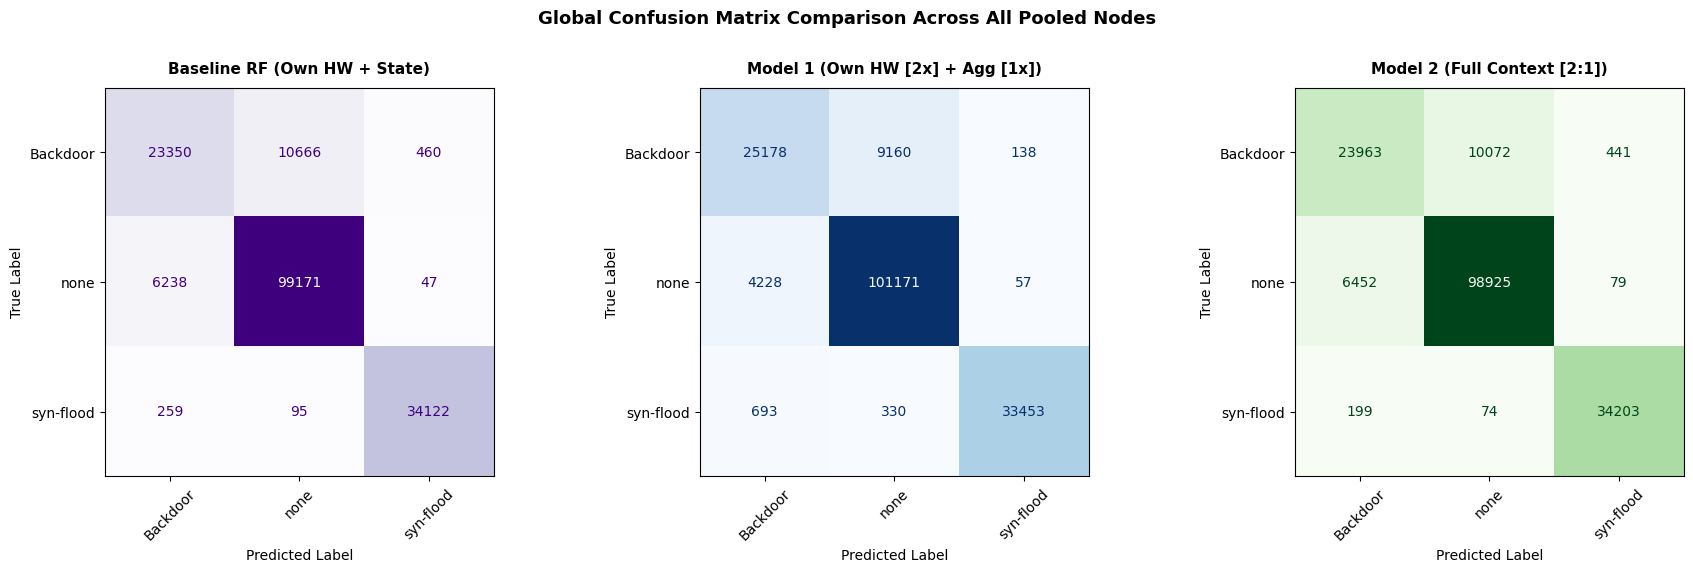

In [22]:
# Cell 4
# =============================================================================
# Side-by-Side Confusion Matrix Plots (Baseline vs. 2:1 Weighted Context Models)
# =============================================================================

import os
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# -----------------------------------------------------------------------------
# 1. Baseline RF
# -----------------------------------------------------------------------------
cm_base = confusion_matrix(
    df_pred_base["Attack"], df_pred_base["prediction"], labels=classes
)
disp_base = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=classes)
disp_base.plot(ax=axes[0], cmap="Purples", values_format="d", colorbar=False)
axes[0].set_title("Baseline RF (Own HW + State)", fontsize=11, fontweight="bold", pad=10)
axes[0].set_xlabel("Predicted Label", fontsize=10)
axes[0].set_ylabel("True Label", fontsize=10)
axes[0].tick_params(axis="x", rotation=45)

# -----------------------------------------------------------------------------
# 2. Model 1: Own HW (2x) + Agg Context (1x) [No State]
# -----------------------------------------------------------------------------
cm1 = confusion_matrix(
    df_pred_hw_agg["Attack"], df_pred_hw_agg["prediction"], labels=classes
)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=classes)
disp1.plot(ax=axes[1], cmap="Blues", values_format="d", colorbar=False)
axes[1].set_title(
    "Model 1 (Own HW [2x] + Agg [1x])", fontsize=11, fontweight="bold", pad=10
)
axes[1].set_xlabel("Predicted Label", fontsize=10)
axes[1].set_ylabel("True Label", fontsize=10)
axes[1].tick_params(axis="x", rotation=45)

# -----------------------------------------------------------------------------
# 3. Model 2: Full Context (Own HW/Probs [2x] + Agg [1x]) [No State]
# -----------------------------------------------------------------------------
cm2 = confusion_matrix(
    df_pred_full["Attack"], df_pred_full["prediction"], labels=classes
)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=classes)
disp2.plot(ax=axes[2], cmap="Greens", values_format="d", colorbar=False)
axes[2].set_title(
    "Model 2 (Full Context [2:1])", fontsize=11, fontweight="bold", pad=10
)
axes[2].set_xlabel("Predicted Label", fontsize=10)
axes[2].set_ylabel("True Label", fontsize=10)
axes[2].tick_params(axis="x", rotation=45)

fig.suptitle(
    "Global Confusion Matrix Comparison Across All Pooled Nodes",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()

# Save the plot
output_path = os.path.join(PLOTS_DIR, "confusion_matrices_comparison_w2.png")
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved confusion matrix comparison plot to '{output_path}'")

plt.show()
plt.close(fig)

Saved ROC curves comparison plot to 'plots/roc_curves_comparison_w2.png'


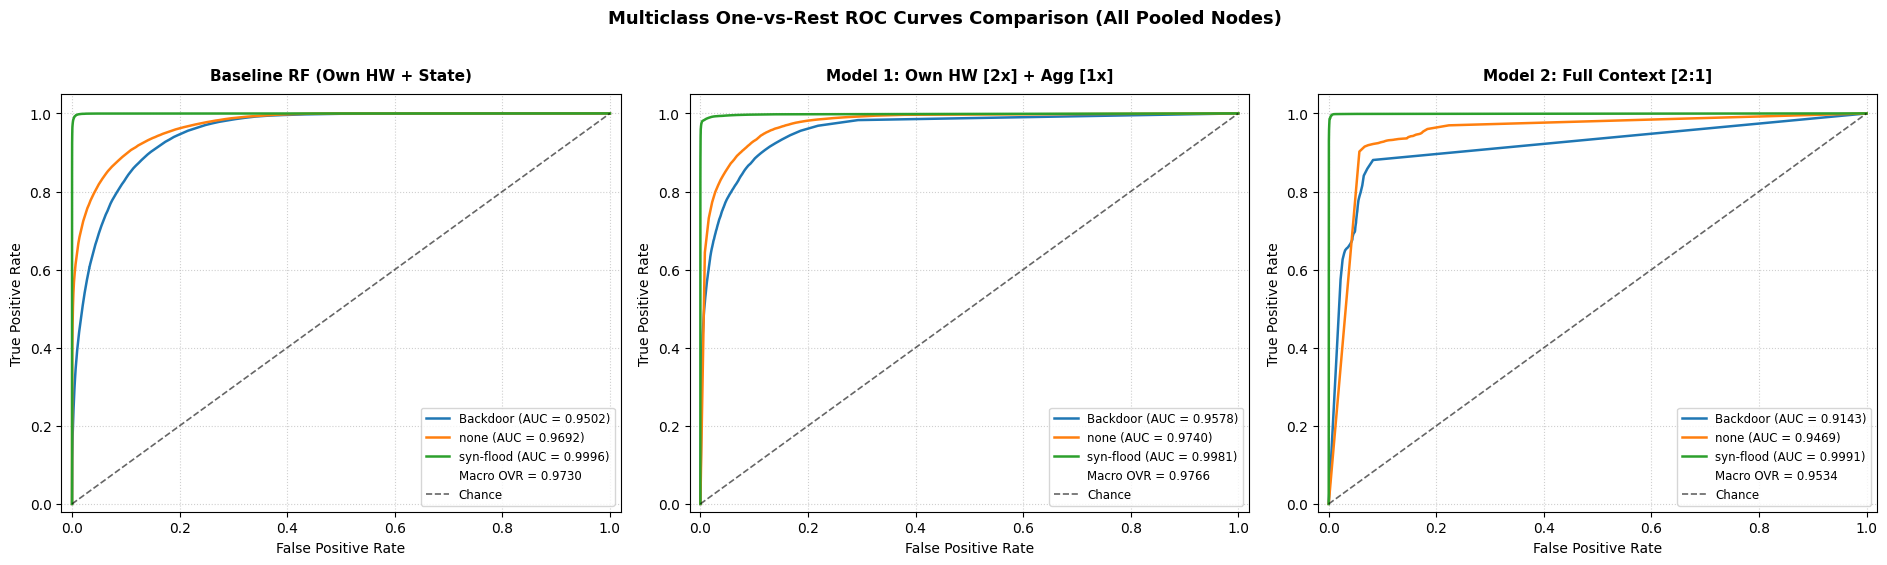

In [23]:
# Cell 5
# =============================================================================
# Multiclass ROC Curves Comparison (Baseline vs. 2:1 Weighted Context Models)
# =============================================================================

import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import auc, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

num_classes = len(classes)
y_true_indices = le_context.transform(df_pred_base["Attack"])
y_test_bin = label_binarize(y_true_indices, classes=range(num_classes))
prob_cols = [f"prob_{cls_name}" for cls_name in classes]

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

model_dfs = [
    (df_pred_base, "Baseline RF (Own HW + State)", axes[0]),
    (df_pred_hw_agg, "Model 1: Own HW [2x] + Agg [1x]", axes[1]),
    (df_pred_full, "Model 2: Full Context [2:1]", axes[2])
]

for df_preds, title, ax in model_dfs:
    y_prob = df_preds[prob_cols].values

    # Plot One-vs-Rest ROC curve for each individual class
    for i, cls_name in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_score = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=1.8, label=f"{cls_name} (AUC = {roc_score:.4f})")

    # Compute and plot the Macro-Average ROC score
    try:
        macro_ovr_auc = roc_auc_score(
            y_true_indices,
            y_prob,
            multi_class="ovr",
            average="macro",
            labels=np.arange(num_classes)
        )
        ax.plot([], [], " ", label=f"Macro OVR = {macro_ovr_auc:.4f}")
    except ValueError:
        pass

    # Baseline diagonal line (Random Classifier)
    ax.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.6, label="Chance")
    
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    ax.set_xlabel("False Positive Rate", fontsize=10)
    ax.set_ylabel("True Positive Rate", fontsize=10)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.05])
    ax.legend(loc="lower right", fontsize=8.5, frameon=True)
    ax.grid(True, linestyle=":", alpha=0.6)

fig.suptitle(
    "Multiclass One-vs-Rest ROC Curves Comparison (All Pooled Nodes)",
    fontsize=13,
    fontweight="bold",
    y=1.02
)
plt.tight_layout()

# Save figure
output_path = os.path.join(PLOTS_DIR, "roc_curves_comparison_w2.png")
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved ROC curves comparison plot to '{output_path}'")

plt.show()
plt.close(fig)

Saved feature importance comparison plot to 'plots/feature_importance_3model_comparison_w2.png'


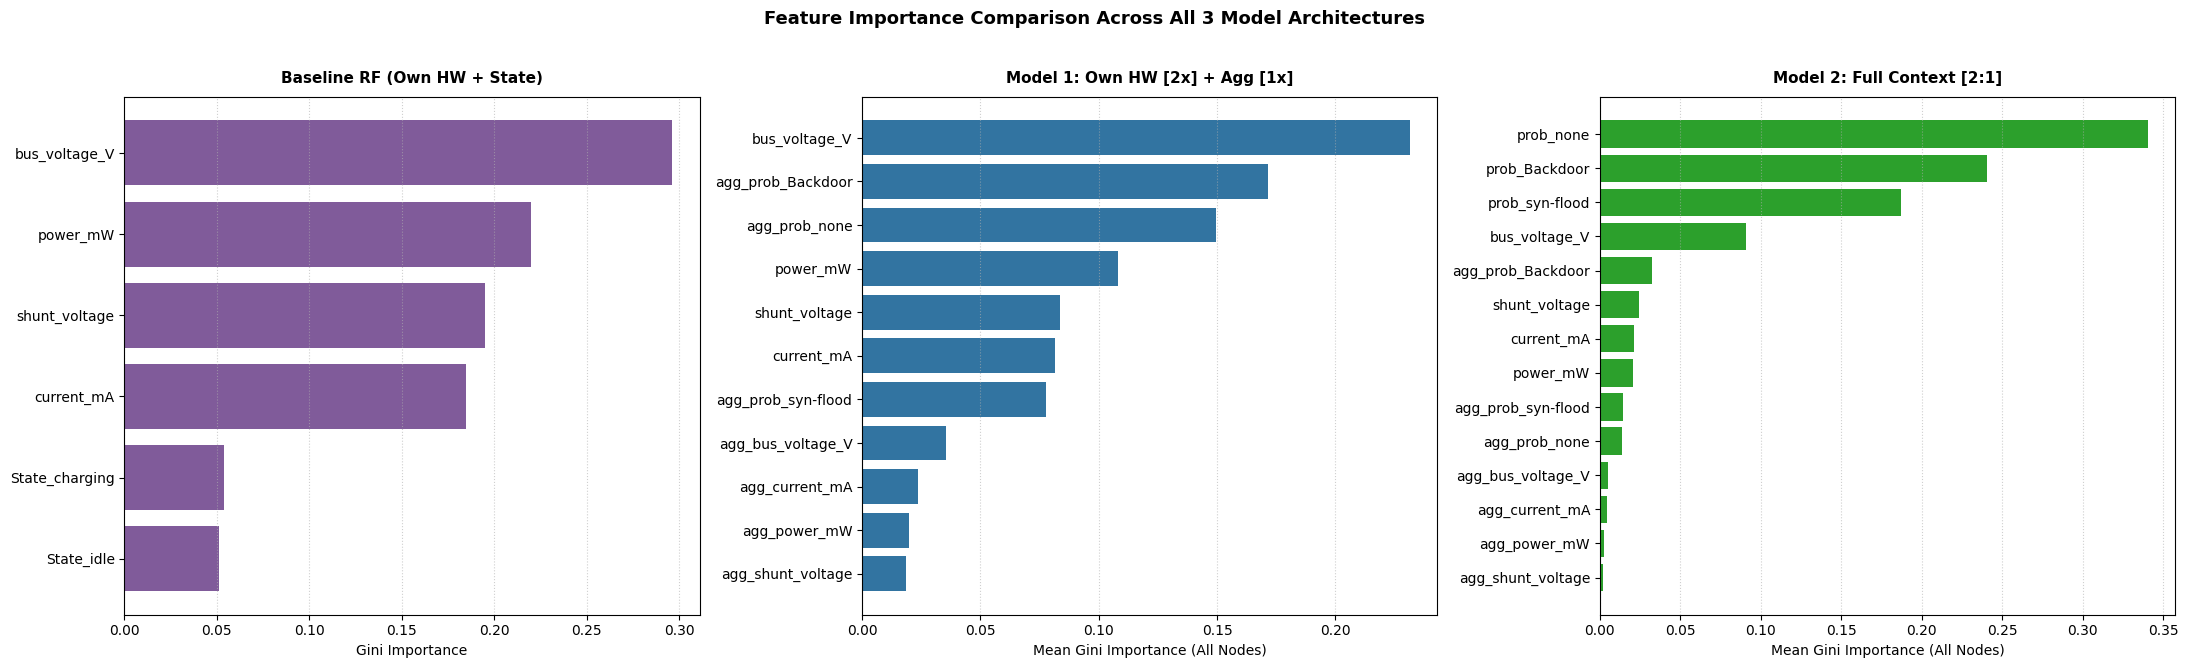

In [24]:
# Cell 6
# =============================================================================
# Feature Importance Comparison Across All 3 Model Variations
# =============================================================================

import os
import joblib
import matplotlib.pyplot as plt
import pandas as pd

MODELS_DIR = "models"
PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# -----------------------------------------------------------------------------
# 1. Baseline Model Feature Importance (Global Model with State)
# -----------------------------------------------------------------------------
rf_base = joblib.load(os.path.join(MODELS_DIR, "rf_final.joblib"))
feat_base = [
    "shunt_voltage", "bus_voltage_V", "current_mA", "power_mW",
    "State_idle", "State_charging"
]

df_imp_base = pd.DataFrame({
    "Feature": feat_base,
    "Importance": rf_base.feature_importances_
}).sort_values("Importance", ascending=True)

# -----------------------------------------------------------------------------
# 2. Average Feature Importances Across All Nodes for Model 1 & Model 2 (2:1 Weighted)
# -----------------------------------------------------------------------------
all_imp1_list = []
all_imp2_list = []

for node in NODES:
    # Load node-specific models
    rf_m1 = joblib.load(os.path.join(MODELS_DIR, f"Node_{node}_rf_context_own_hw_plus_agg_w2.joblib"))
    rf_m2 = joblib.load(os.path.join(MODELS_DIR, f"Node_{node}_rf_context_full_w2.joblib"))

    # Load node-specific feature lists
    feat_m1 = pd.read_csv(os.path.join(MODELS_DIR, f"Node_{node}_feature_list_own_hw_plus_agg_w2.csv"))["feature"].tolist()
    feat_m2 = pd.read_csv(os.path.join(MODELS_DIR, f"Node_{node}_feature_list_context_full_w2.csv"))["feature"].tolist()

    # Model 1: Strip '_w2' and sum duplicates
    df_raw1 = pd.DataFrame({
        "Feature": [f.replace("_w2", "") for f in feat_m1],
        "Importance": rf_m1.feature_importances_
    })
    df_grouped1 = df_raw1.groupby("Feature", as_index=False).sum()
    all_imp1_list.append(df_grouped1)

    # Model 2: Strip '_w2' and sum duplicates
    df_raw2 = pd.DataFrame({
        "Feature": [f.replace("_w2", "") for f in feat_m2],
        "Importance": rf_m2.feature_importances_
    })
    df_grouped2 = df_raw2.groupby("Feature", as_index=False).sum()
    all_imp2_list.append(df_grouped2)

# Compute mean importance across all nodes
df_imp_1 = (
    pd.concat(all_imp1_list, ignore_index=True)
    .groupby("Feature", as_index=False)["Importance"]
    .mean()
    .sort_values("Importance", ascending=True)
)

df_imp_2 = (
    pd.concat(all_imp2_list, ignore_index=True)
    .groupby("Feature", as_index=False)["Importance"]
    .mean()
    .sort_values("Importance", ascending=True)
)

# -----------------------------------------------------------------------------
# 3. Side-by-Side 3-Panel Plot
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(22, 6.5))

# Baseline
axes[0].barh(df_imp_base["Feature"], df_imp_base["Importance"], color="#805B9A")
axes[0].set_title("Baseline RF (Own HW + State)", fontsize=11, fontweight="bold", pad=10)
axes[0].set_xlabel("Gini Importance", fontsize=10)
axes[0].grid(True, axis="x", linestyle=":", alpha=0.6)

# Model 1
axes[1].barh(df_imp_1["Feature"], df_imp_1["Importance"], color="#3274A1")
axes[1].set_title("Model 1: Own HW [2x] + Agg [1x]", fontsize=11, fontweight="bold", pad=10)
axes[1].set_xlabel("Mean Gini Importance (All Nodes)", fontsize=10)
axes[1].grid(True, axis="x", linestyle=":", alpha=0.6)

# Model 2
axes[2].barh(df_imp_2["Feature"], df_imp_2["Importance"], color="#2CA02C")
axes[2].set_title("Model 2: Full Context [2:1]", fontsize=11, fontweight="bold", pad=10)
axes[2].set_xlabel("Mean Gini Importance (All Nodes)", fontsize=10)
axes[2].grid(True, axis="x", linestyle=":", alpha=0.6)

fig.suptitle(
    "Feature Importance Comparison Across All 3 Model Architectures",
    fontsize=13,
    fontweight="bold",
    y=1.02
)
plt.tight_layout()

# Save plot
output_path = os.path.join(PLOTS_DIR, "feature_importance_3model_comparison_w2.png")
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved feature importance comparison plot to '{output_path}'")

plt.show()
plt.close(fig)